In [1]:
%load_ext autoreload
%autoreload 2

import os,sys
import util as yu
from util import *
import util_charge as yuc

yu.setpath('check_Srijit')

enss=['b']

In [2]:
symmetrizeQ=False
extraLabel='' if symmetrizeQ else '_0sym'

[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl_reg('ens2pars_jk_meffnst_selected',pathlabel='analysis_c2pt')

ens2data={}
for ens in enss:
    path=f'/p/project1/ngff/li47/code/projectData/07_Nsgm/charges/{yu.ens2full[ens]}.h5'
    [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=yuc.load(path,symmetrizeQ=symmetrizeQ)
    ens2data[ens]=[c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]

In [3]:
# for g in ['gS+;disc']:
#     for ens in enss:
#         pars_jk_meff2st=ens2pars_jk_meff2st[ens]
#         [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=ens2data[ens]
#         tf2ratio=key2tf2ratio[g]
        
#         xunit=yu.ens2a[ens]
#         fig,axs=yu.makePlot_3pt_rainbow(tf2ratio,tfmin=8,tfmax=1.5/xunit,xunit=xunit,dt=2)
#         axs[0,0].set_ylim([-4,4])
#         yu.finalizePlot()

347(24)


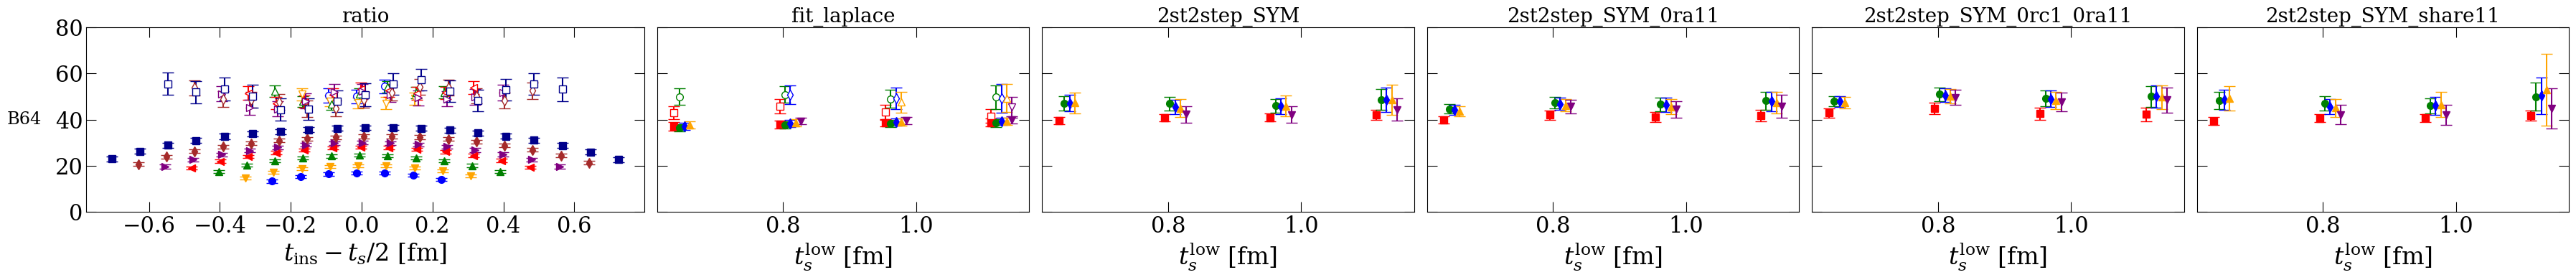

In [5]:
ds_global=[1,1]

for g in ['gS+']:
    ens2dics={}
    for ens in enss:
        pars_jk_meff2st=ens2pars_jk_meff2st[ens]
        [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=ens2data[ens]
        tf2ratio=key2tf2ratio[g]
        
        tfmins_2st=tfs_conn[:-3]
        # tcmins_2st=np.arange(1,int(0.5/yu.ens2a[ens]),int(0.2/yu.ens2a[ens]))
        tcmins_2st=np.arange(1,round(0.45/yu.ens2a[ens]))
        
        label2fits={}; label2fits_ds2={}; label2fits_unc={}
        for label in ['2st2step_SYM','2st2step_SYMshare','2st2step_SYM_0ra11','2st2step_SYM_0rc1_0ra11','2st2step_SYM_share11']:
            # print(ens,label)
            # label2fits[label]=yu.doFits_3pt(label,tf2ratio,tfmins_2st,tcmins_2st,pars_jk_meff2st=pars_jk_meff2st,symmetrizeQ=symmetrizeQ,label=f'{g}_{ens}_{label}',verbose=1)
            label2fits_ds2[label]=yu.doFits_3pt(label,tf2ratio,tfmins_2st,tcmins_2st,pars_jk_meff2st=pars_jk_meff2st,symmetrizeQ=symmetrizeQ,label=f'{g}_{ens}_{label}_ds2',verbose=1,downSampling=ds_global)
            
            
        # n=int(0.2/yu.ens2a[ens])
        n=2
        def dE2lbd(dE):
            lbd0=dE*n
            return np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)
        
        def lbd2tf2ratio(dE):    
            lbd=dE2lbd(dE)
            
            tf2ratio={}
            for tf in tfs_conn:
                c3=key2tf2c3pt[g][tf]
                c3=-(np.roll(c3,-n,axis=-1)+np.roll(c3,n,axis=-1)-2*c3) + lbd**2*c3
                c2=(lbd**2)*c2pt_disc[:,tf]
                tf2ratio[tf]=c3/c2[:,None]
            return tf2ratio
        tfmins=tfmins_2st
        tcmins=[n+tcmin for tcmin in tcmins_2st]
        
        fits_laplace_ds2=yu.doFits_3pt_lbd(lbd2tf2ratio,tfmins,tcmins,symmetrizeQ=symmetrizeQ,label=f'{g}_{ens}_lbd_ds2',verbose=1,downSampling=ds_global,overwrite=False)
        fits_laplace_ds2=[[(tfmin,tcmin),np.array([pars_jk[:,0],np.abs(pars_jk[:,1])]).T,chi2_jk,Ndof] for (tfmin,tcmin),pars_jk,chi2_jk,Ndof in fits_laplace_ds2]

        fitlabel_chosen=(8,n+2)
        # fitlabel_chosen=fits_laplace_ds2[0][0]
        fit_MA_laplace=yu.doMA_3pt(fits_laplace_ds2,fitlabels=fitlabel_chosen)
        print(yu.jackme_un2str(fit_MA_laplace[0][:,1]*yu.ens2aInv[ens]))

        dE=np.mean(fit_MA_laplace[0][:,1])
        tf2ratio_laplace=lbd2tf2ratio(dE)
        # fits_const_2=yu.doFits_3pt('const',tf2ratio_laplace,tfmins,tcmins,symmetrizeQ=symmetrizeQ,label=f'const_2_laplace'+extraLabel)
        # fit_const_MA_2=yu.doMA_3pt(fits_const_2,fitlabels=fitlabel_chosen)

        xunit=yu.ens2a[ens]
        yunit=yu.ens2amul_iso[ens]*yu.ens2aInv[ens]
        
        dic={
            'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,None,None,None,None],
            'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
            'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,1,None],
            'xyunit':[xunit,yunit],
            'mfc:[global]':['None'],
        }
        dic_lbd={
            'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio_laplace,None,fits_laplace_ds2,None,None],
            'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
            'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,n+1,None],
            'xyunit':[xunit,yunit],
            'mfc:[global]':['white'],
        }
        
        label2dic={}
        for label in label2fits_ds2.keys():
            label2dic[label]={
                'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[None,None,None,None,label2fits_ds2[label]],
                'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
                'fit_2st:[tfmin_min,tfmin_max,tcmin_min,tcmin_max,dtf,dtc]':[None,None,None,5,None,None],
                'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,1,None],
                'xyunit':[xunit,yunit],
                'mfc:[global]':['None'],
            }
        
        ens2dics[ens]=[dic,dic_lbd,label2dic]
    
        
    colHeaders=['ratio','fit_laplace','2st2step_SYM','2st2step_SYM_0ra11','2st2step_SYM_0rc1_0ra11','2st2step_SYM_share11']
    fig,axs=yu.makePlot_3pt([ens2dics[ens][0] for ens in enss],shows=['rainbow'],colHeaders=colHeaders,fontsize_colHeaders=20, sharey=True)
    yu.addRowHeader(axs,[yu.ens2label[ens] for ens in enss])
    axs[0,0].set_ylim([0,80])
    fig,axs=yu.makePlot_3pt([ens2dics[ens][1] for ens in enss],shows=['rainbow']+[None]*(colHeaders.index('fit_laplace')-1)+['fit_const'],figAxs=(fig,axs),colHeaders=None)
    
    for i,label in enumerate(colHeaders):
        if label in label2dic.keys(): 
            fig,axs=yu.makePlot_3pt([ens2dics[ens][2][label] for ens in enss],shows=['rainbow']+[None]*(i-1)+['fit_2st'],figAxs=(fig,axs),colHeaders=None)
    fig,axs=yu.makePlot_3pt([ens2dics[ens][2]['2st2step_SYMshare'] for ens in enss],shows=['rainbow','fit_2st'],figAxs=(fig,axs),colHeaders=None)
            
    yu.finalizePlot()

In [14]:
g='gS+'; ens='b'; label='2st2step_SYM'
fits=yu.getFits(f'{g}_{ens}_{label}_ds2')
# fit=[fit for fit in fits if fit[0]==(8,1)][0]
print(yu.ens2amul_iso[ens]*yu.ens2aInv[ens])
yu.printFits(fits)

1.6555028938097638
Model average: pars=['28.3(1.8)', '0.158(14)', '-16.5(1.6)', '0.0(4.4)'], most probable fitlabel: (10, 2), prob=69%, chi2/Ndof=65.4/68=0.9;
fitlabel=(8, 1), pars=['23.87(92)', '0.208(12)', '-13.18(78)', '-3.9(3.2)'], prob=0%, chi2/Ndof=121.6/87=1.3;
fitlabel=(8, 2), pars=['28.4(1.9)', '0.154(14)', '-16.9(1.7)', '4.7(3.3)'], prob=22%, chi2/Ndof=77.6/73=1.0;
fitlabel=(8, 3), pars=['28.4(2.2)', '0.154(17)', '-17.0(1.9)', '4.9(3.8)'], prob=0%, chi2/Ndof=68.2/59=1.1;
fitlabel=(8, 4), pars=['28.5(2.7)', '0.153(22)', '-17.4(2.4)', '6.1(4.8)'], prob=0%, chi2/Ndof=53.4/45=1.1;
fitlabel=(10, 1), pars=['24.7(1.0)', '0.204(13)', '-13.47(89)', '-11.2(5.4)'], prob=0%, chi2/Ndof=100.1/80=1.2;
fitlabel=(10, 2), pars=['28.4(1.8)', '0.159(14)', '-16.4(1.6)', '-1.1(4.8)'], prob=69%, chi2/Ndof=65.4/68=0.9;
fitlabel=(10, 3), pars=['27.5(1.9)', '0.168(18)', '-15.8(1.6)', '-3.3(5.8)'], prob=0%, chi2/Ndof=55.8/56=0.9;
fitlabel=(10, 4), pars=['27.2(2.3)', '0.171(24)', '-15.7(1.9)', '-2.8(7.4

In [37]:
path='data_aux/sgm_ChPT.csv'
df=pd.read_csv(path, index_col=0)
def func(ele):
    m,e=ele.split(',')
    m=m.split('(')[-1]
    e=e.split(')')[0]
    return float(m),float(e)

dic_sgm_ChPT={(row_label, col_label): func(df.loc[row_label, col_label])
    for row_label in df.index
    for col_label in df.columns
}

(0.8, 0.3) fm = [(10, 4), (12, 4), (14, 5), (17, 6)]
(0.8, 0.3) fm = [(10, 4), (12, 4), (14, 5), (17, 6)]


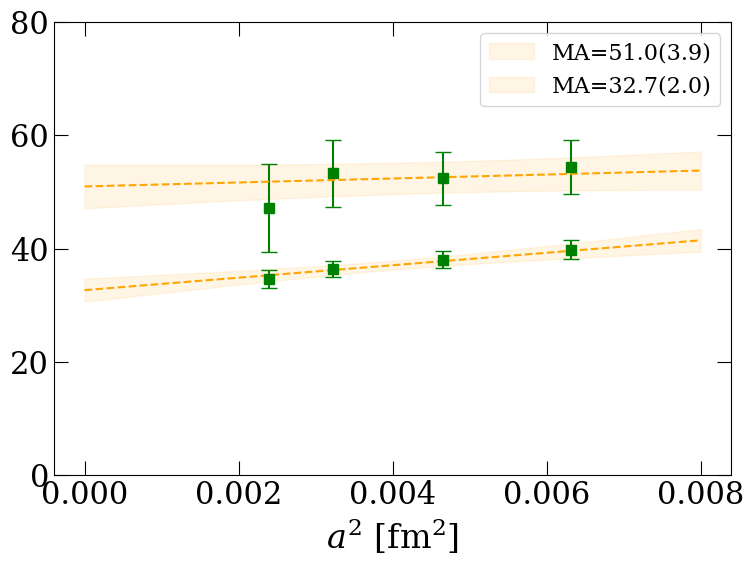

In [50]:

def get(tfphy,tcphy,label,ds='_ds2'):
    ens2dat={}; fitlabels=[]
    for ens in enss:
        [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=ens2data[ens]
        
        ind=np.argmin(np.abs(tfphy-np.array(tfs_conn)*yu.ens2a[ens]))
        tfmin=tfs_conn[ind]
        tcmin=round(tcphy/yu.ens2a[ens])
        fitlabel=(tfmin,tcmin)
        fitlabels.append(fitlabel)
        
        g='gS+'
        fits=yu.getFits(f'{g}_{ens}_{label}{ds}')
        fit=[fit for fit in fits if fit[0]==fitlabel][0]
        
        sgm=fit[1][:,0] * yu.ens2amul_iso[ens] * yu.ens2aInv[ens]
        
        Njk=len(c2pt_disc)
        m,e=dic_sgm_ChPT[(yu.ens2label[ens],'ratio_N3LO')]
        factor=yu.jackknife_pseudo(m,e,Njk)[:,0]
        sgm=fit[1][:,0] * yu.ens2amul[ens] * yu.ens2aInv[ens] * factor
        
        # m,e=dic_sgm_ChPT[(yu.ens2label[ens],'diff_N3LO')]
        # factor=yu.jackknife_pseudo(m,e,Njk)[:,0]
        # sgm=fit[1][:,0] * yu.ens2amul[ens] * yu.ens2aInv[ens] + factor
        
        ens2dat[ens]=sgm
    print(f'{(tfphy,tcphy)} fm = {fitlabels}')
    return ens2dat

ens2dat=get(0.8,0.3,'lbd')
fits=yu.doFits_continuumExtrapolation(ens2dat,yuc.lat_a2s_plt)
dic={
    'ens2dat': ens2dat,
    'fit:[fits,lat_a2s_plt]':[fits,yuc.lat_a2s_plt]
}
fig,axs=yu.makePlot_continuumExtrapolation(dic)
ax=axs[0,0]
ax.set_ylim([0,80])

ens2dat=get(0.8,0.3,'2st2step_SYMshare')
fits=yu.doFits_continuumExtrapolation(ens2dat,yuc.lat_a2s_plt)
dic={
    'ens2dat': ens2dat,
    'fit:[fits,lat_a2s_plt]':[fits,yuc.lat_a2s_plt]
}
fig,axs=yu.makePlot_continuumExtrapolation(dic,figAxs=(fig,axs))

yu.finalizePlot()

(0.9, 0.2) fm = [(12, 3), (14, 3), (16, 4), (17, 4)]


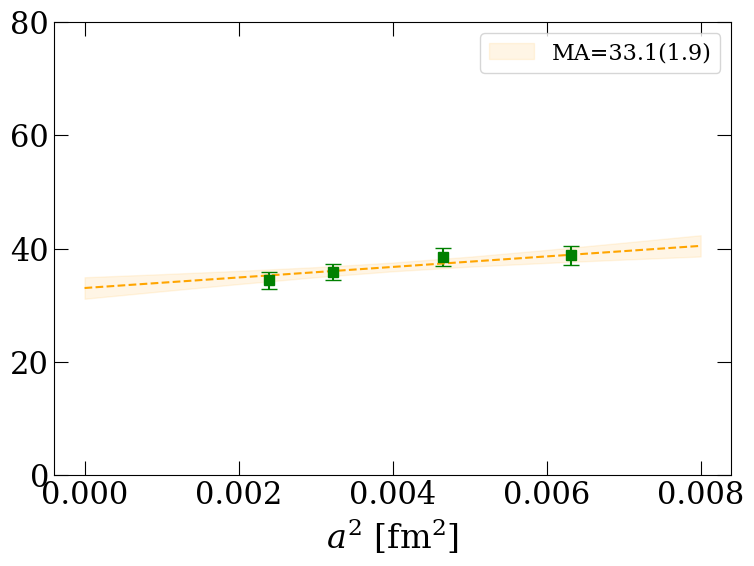

In [6]:
def get(tfphy,tcphy,label,ds='_ds2'):
    ens2dat={}; fitlabels=[]
    for ens in enss:
        [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=ens2data[ens]
        
        ind=np.argmin(np.abs(tfphy-np.array(tfs_conn)*yu.ens2a[ens]))
        tfmin=tfs_conn[ind]
        tcmin=round(tcphy/yu.ens2a[ens])
        fitlabel=(tfmin,tcmin)
        fitlabels.append(fitlabel)
        
        g='gS+'
        fits=yu.getFits(f'{g}_{ens}_{label}{ds}')
        fit=[fit for fit in fits if fit[0]==fitlabel][0]
        
        sgm=fit[1][:,0] * yu.ens2amul_iso[ens] * yu.ens2aInv[ens]
        
        ens2dat[ens]=sgm
    print(f'{(tfphy,tcphy)} fm = {fitlabels}')
    return ens2dat


ens2dat=get(0.9,0.2,'2st2step_SYMshare')
fits=yu.doFits_continuumExtrapolation(ens2dat,yuc.lat_a2s_plt)
dic={
    'ens2dat': ens2dat,
    'fit:[fits,lat_a2s_plt]':[fits,yuc.lat_a2s_plt]
}
fig,axs=yu.makePlot_continuumExtrapolation(dic)
ax=axs[0,0]
ax.set_ylim([0,80])
yu.finalizePlot()